In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_json('../data/01_ptf.json')
df.head()

,date,hour,price,priceUsd,priceEur
0,2020-07-01 00:00:00+03:00,00:00,323.85,47.33,42.01
1,2020-07-01 01:00:00+03:00,01:00,326.95,47.78,42.42
2,2020-07-01 02:00:00+03:00,02:00,324.31,47.40,42.07
3,2020-07-01 03:00:00+03:00,03:00,322.11,47.08,41.79
4,2020-07-01 04:00:00+03:00,04:00,320.00,46.77,41.51


In [3]:
[df[column].dtype for column in df.columns]

[datetime64[us, UTC+03:00],
 <StringDtype(storage='python', na_value=nan)>,
 dtype('float64'),
 dtype('float64'),
 dtype('float64')]

In [4]:
df = df.set_index('date')
df.describe()

,price,priceUsd,priceEur
count,53040.000000,53040.000000,53040.000000
mean,1838.495663,78.472357,71.860103
std,1174.960481,48.758017,48.225300
min,0.000000,0.000000,0.000000
25%,612.507500,44.550000,38.170000
50%,1999.970000,72.250000,64.450000
75%,2700.000000,88.222500,81.500000
max,4800.000000,264.170000,271.630000


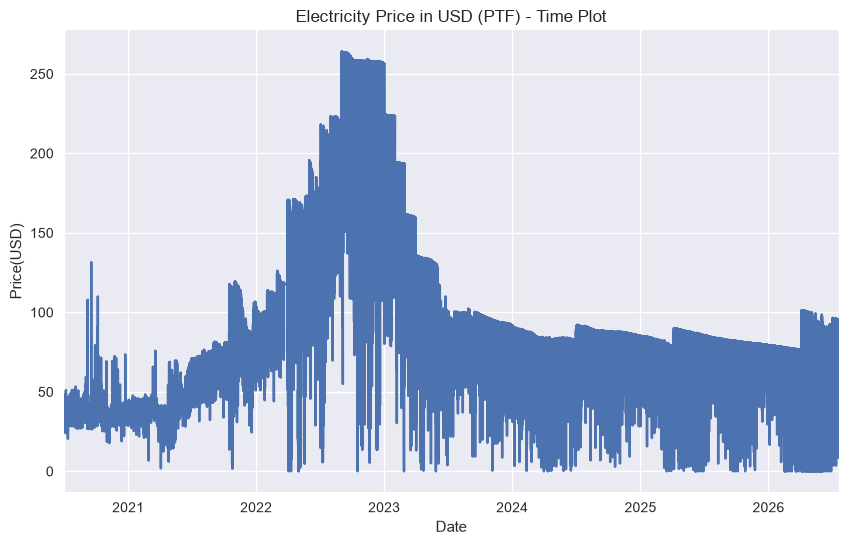

In [5]:
plt.style.use("seaborn-v0_8")

plt.figure(figsize=(10,6))
df['priceUsd'].plot(title='Electricity Price in USD (PTF) - Time Plot')
plt.ylabel('Price(USD)')
plt.xlabel('Date')
plt.show()

In [6]:
df['year'] = df.index.year
df['month'] = df.index.month
df.reset_index(inplace=True)
df.head()

,date,hour,price,priceUsd,priceEur,year,month
0,2020-07-01 00:00:00+03:00,00:00,323.85,47.33,42.01,2020,7
1,2020-07-01 01:00:00+03:00,01:00,326.95,47.78,42.42,2020,7
2,2020-07-01 02:00:00+03:00,02:00,324.31,47.40,42.07,2020,7
3,2020-07-01 03:00:00+03:00,03:00,322.11,47.08,41.79,2020,7
4,2020-07-01 04:00:00+03:00,04:00,320.00,46.77,41.51,2020,7


In [7]:
df['week'] = df['date'].dt.isocalendar().week
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.dayofweek
df['day_str'] = df['date'].dt.strftime('%a')
df['year_month'] = df['date'].dt.strftime('%Y_%m')
df.set_index('date', inplace=True)


In [8]:
df.tail()

,hour,price,priceUsd,priceEur,year,month,week,day,day_str,year_month
date,,,,,,,,,,
2026-07-19 19:00:00+03:00,19,3744.01,79.68,69.66,2026,7,29,6,Sun,2026_07
2026-07-19 20:00:00+03:00,20,4298.88,91.49,79.98,2026,7,29,6,Sun,2026_07
2026-07-19 21:00:00+03:00,21,4400.01,93.65,81.87,2026,7,29,6,Sun,2026_07
2026-07-19 22:00:00+03:00,22,3996.00,85.05,74.35,2026,7,29,6,Sun,2026_07
2026-07-19 23:00:00+03:00,23,3777.01,80.39,70.27,2026,7,29,6,Sun,2026_07


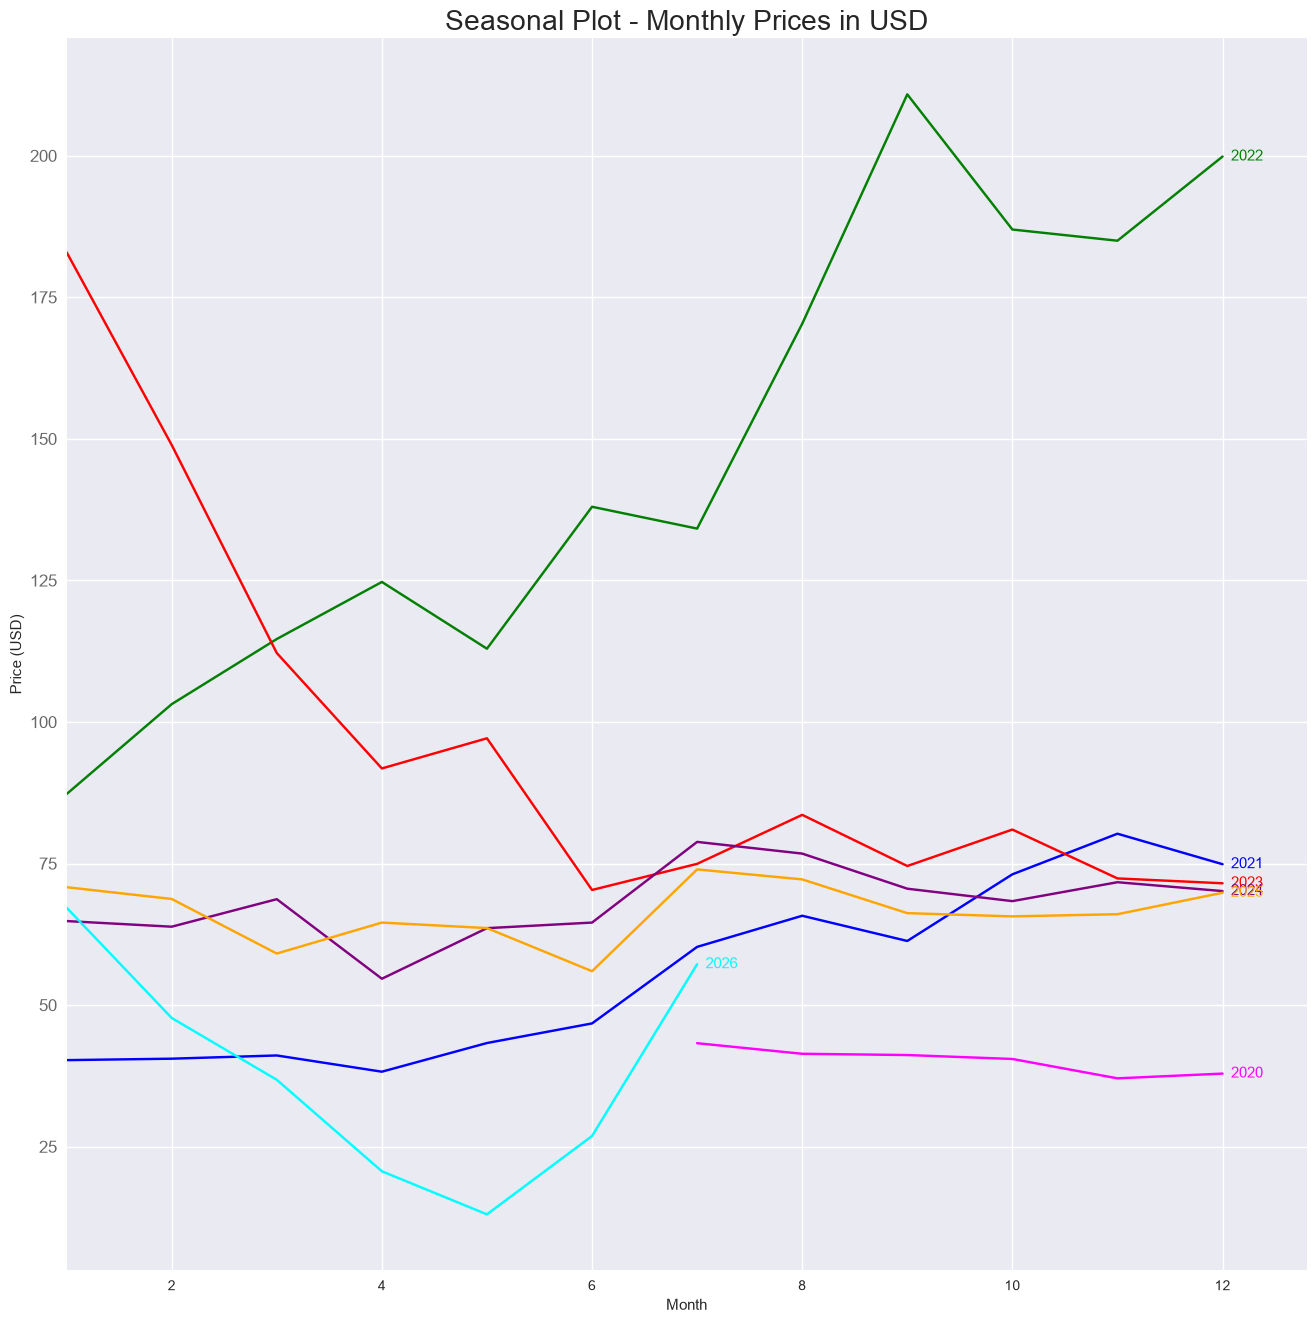

In [13]:
np.random.seed(42)

df_plot = df[['month', 'year', 'priceUsd']].dropna().groupby(['month', 'year'])['priceUsd'].mean().reset_index()

years = df_plot['year'].unique()

colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan', 
          'magenta', 'yellow', 'brown', 'black']

plt.figure(figsize=(16, 16))

for i, y in enumerate(years):
    if i < len(colors):
        year_data = df_plot[df_plot['year'] == y].sort_values('month')
        plt.plot('month', 'priceUsd', data=year_data, color=colors[i], label=y)

        last_point = year_data.dropna(subset=['priceUsd']).iloc[-1]
        plt.text(
            last_point['month'] + 0.08,
            last_point['priceUsd'],
            str(y),
            color=colors[i],
            va='center',
            fontsize=11,
        )
    else:
        print('Not enough colors.')


plt.gca().set(ylabel='Price (USD)', xlabel='Month')
plt.xlim(1, 12.8)
plt.yticks(fontsize=12, alpha=.7)
plt.title('Seasonal Plot - Monthly Prices in USD', fontsize=20)
plt.show()
